```.venv\Scripts\activate```

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from sklearn import preprocessing
pd.set_option('display.max_columns', None)

In [5]:
df_raw = pd.read_csv('data/processed/atx_crash_data_2018-2026_clean.csv')

C:\Users\emily.wilkins\AppData\Local\Temp\ipykernel_19312\1525999005.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv('data/processed/atx_crash_data_2018-2026_clean.csv')


In [6]:
df_raw.head()

,ID,Crash ID,crash_fatal_fl,case_id,rpt_block_num,rpt_street_name,rpt_street_sfx,crash_speed_limit,road_constr_zone_fl,latitude,longitude,crash_sev_id,death_cnt,point,onsys_fl,private_dr_fl,Crash timestamp (US/Central),Estimated Total Comprehensive Cost,Location group,Address,day_of_week,week_of_year,hour_of_day,micromobility device_involved,train_involved,e-scooter_involved,pedestrian_involved,motorcycle_involved,large passenger vehicle_involved,bicycle_involved,passenger car_involved,motor vehicle – other_involved
0,92807,16839445.0,False,190080930,1200,MOPAC,EXPY,65.0,False,30.288379,-97.762235,5,0,POINT (-97.76223487 30.28837926),True,False,2019-01-09 14:12:00,20000,2.0,1200 N LOOP 1,2,2,14,False,False,False,False,False,True,False,True,False
1,93467,16854755.0,False,190151441,1700,OHLEN,RD,35.0,False,30.363175,-97.717782,5,0,POINT (-97.71778247 30.36317476),True,False,2019-01-15 20:58:00,40000,1.0,W OHLEN RD & N US 183 SVRD,1,3,20,False,False,False,False,False,False,False,True,False
2,93480,16854819.0,False,190160293,3100,IH 35,HWY,60.0,False,30.234100,-97.740976,5,0,POINT (-97.7409757 30.23410002),True,False,2019-01-16 07:28:00,40000,2.0,3100 S IH 35,2,3,7,False,False,False,False,False,True,False,False,False
3,94289,16870096.0,False,190260764,300,E PARMER,LN,50.0,False,30.405288,-97.663709,3,0,POINT (-97.6637086677118 30.405287627981),False,False,2019-01-26 13:41:00,460000,1.0,E PARMER LN & MC CALLEN PASS,5,4,13,False,False,False,False,False,True,False,False,False
4,93948,16863200.0,False,190230902,8900,GALEWOOD,DR,25.0,False,30.366156,-97.715854,2,0,POINT (-97.71585363 30.3661555),False,False,2019-01-23 13:25:00,540000,1.0,8900 GALEWOOD DR,2,4,13,False,False,False,False,False,True,False,True,False


In [7]:
drop_cols = ['ID','Crash ID','case_id','rpt_street_sfx','point','Address','crash_sev_id','crash_fatal_fl', 'death_cnt', 'rpt_block_num','rpt_street_name','Crash timestamp (US/Central)']
df = df_raw.drop(columns=drop_cols)

In [8]:
df.head()

,crash_speed_limit,road_constr_zone_fl,latitude,longitude,onsys_fl,private_dr_fl,Estimated Total Comprehensive Cost,Location group,day_of_week,week_of_year,hour_of_day,micromobility device_involved,train_involved,e-scooter_involved,pedestrian_involved,motorcycle_involved,large passenger vehicle_involved,bicycle_involved,passenger car_involved,motor vehicle – other_involved
0,65.0,False,30.288379,-97.762235,True,False,20000,2.0,2,2,14,False,False,False,False,False,True,False,True,False
1,35.0,False,30.363175,-97.717782,True,False,40000,1.0,1,3,20,False,False,False,False,False,False,False,True,False
2,60.0,False,30.234100,-97.740976,True,False,40000,2.0,2,3,7,False,False,False,False,False,True,False,False,False
3,50.0,False,30.405288,-97.663709,False,False,460000,1.0,5,4,13,False,False,False,False,False,True,False,False,False
4,25.0,False,30.366156,-97.715854,False,False,540000,1.0,2,4,13,False,False,False,False,False,True,False,True,False


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split, RandomizedSearchCV
import pickle as pkl

In [12]:
target = 'Estimated Total Comprehensive Cost'
df_x = df.drop(columns=[target])
df_y = df[target]

In [15]:
x_train,x_test,y_train,y_test = train_test_split(df_x,df_y,test_size=.2,random_state=42)

In [16]:
params = {
    'n_estimators':[25,50,100,200],
    'criterion': ['squared_error'],
    'max_depth': [3,5,10,None],
    'min_samples_leaf':[1,2,4],
    'max_features': ['sqrt','log2',None]
}

clf = GridSearchCV(RandomForestRegressor(),params,n_jobs=-1,cv=5)

In [18]:
clf.fit(x_train,y_train)

with open('GridSearchTreeRegressor_vf.pkl','wb') as f:
    pkl.dump(clf,f)

In [19]:
best_rf_model = clf.best_estimator_

with open('best_rf_model.pkl', 'wb') as f:
    pickle.dump(best_rf_model, f)

In [20]:
with open('GridSearchTreeFeatures_vf.pkl','wb') as f:
    pkl.dump(df_x.columns,f)

In [21]:
# run to load clf back into notebook
with open('GridSearchTreeRegressor_vf.pkl','rb') as f:
    clf = pkl.load(f)

with open('best_rf_model.pkl','rb') as f:
    best_rf_model = pkl.load(f)    

with open('GridSearchTreeFeatures_vf.pkl','rb') as f:
    cols = pkl.load(f)

In [22]:
print(clf.best_params_)
print(clf.best_score_)

{'criterion': 'squared_error', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
0.08519131939280053


In [24]:
feature_importance = pd.Series(best_rf_model.feature_importances_,index=cols)
feature_importance.sort_values(ascending=False)

pedestrian_involved                 0.189111
longitude                           0.142521
latitude                            0.135499
week_of_year                        0.104046
motorcycle_involved                 0.095407
hour_of_day                         0.088230
crash_speed_limit                   0.071367
day_of_week                         0.049658
onsys_fl                            0.023216
large passenger vehicle_involved    0.021317
bicycle_involved                    0.021016
passenger car_involved              0.015639
road_constr_zone_fl                 0.012189
Location group                      0.010786
motor vehicle – other_involved      0.009347
e-scooter_involved                  0.007151
micromobility device_involved       0.002433
train_involved                      0.001068
private_dr_fl                       0.000000
dtype: float64

# SHAP 


In [25]:
import shap

c:\Users\emily.wilkins\Documents\Projects\pn-bi-to-ai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
#Generate SHAP values
explainer = shap.TreeExplainer(best_rf_model)
shap_values = explainer.shap_values(x_test)

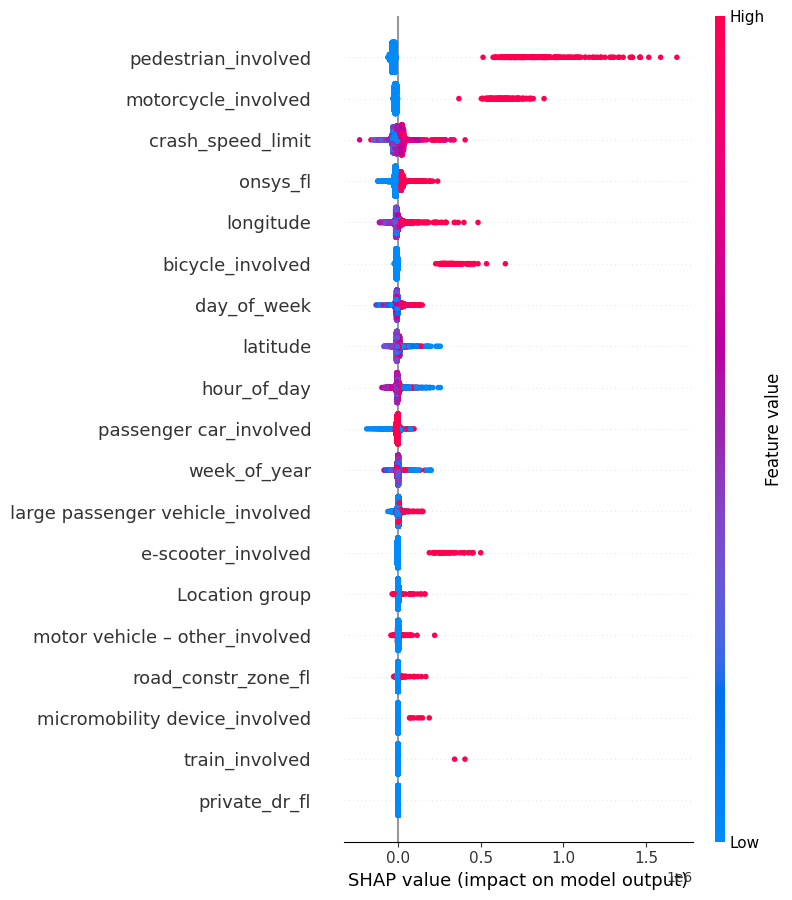

In [27]:
#Create plot and save using Matplotlib
shap.summary_plot(shap_values, x_test, show=False)
plt.savefig('shap_summary_plot.png', bbox_inches='tight', dpi=300)